# 04 – Optimización de Hiperparámetros
**Proyecto:** Sistema de Ventas Retail  
**Asignatura:** SCY1101 – Programación para la Ciencia de Datos

---

## Objetivos
1. Optimizar los mejores modelos del notebook 03 usando **GridSearchCV** y **RandomizedSearchCV**.
2. Documentar el proceso de búsqueda y justificar los espacios de hiperparámetros.
3. Comparar rendimiento antes y después de la optimización.
4. Analizar el impacto de cada hiperparámetro en el rendimiento.
5. Guardar los modelos optimizados para uso en el análisis final.

---

## Modelos a optimizar
| Tarea | Modelo | Método | Justificación |
|-------|--------|--------|---------------|
| Clasificación | Logistic Regression | GridSearchCV | Pocos hiperparámetros, búsqueda exhaustiva viable |
| Clasificación | Random Forest | RandomizedSearchCV | Muchos hiperparámetros, búsqueda aleatoria más eficiente |
| Regresión | Gradient Boosting | RandomizedSearchCV | Reducir overfitting detectado en curvas de aprendizaje |
| Regresión | Random Forest | GridSearchCV | Complementar con segundo modelo optimizado |
---


## 1. Importaciones

In [2]:
import sys, os, warnings, joblib, time
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, KFold, cross_val_score
)
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    r2_score, mean_squared_error, mean_absolute_error,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)

from data_preprocessing import pipeline_completo

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
SEED = 42
np.random.seed(SEED)
THRESHOLD = 0.3

print("✓ Librerías importadas correctamente")


✓ Librerías importadas correctamente


## 2. Carga y Preparación del Dataset

In [3]:
df_ml, *_ = pipeline_completo()

# Limpieza final (idéntica a notebooks anteriores)
df_ml = df_ml[df_ml['total_venta'] > 0].copy()
df_ml['canal_venta'] = df_ml['canal_venta'].fillna(df_ml['canal_venta'].mode()[0])
df_ml['precio_lista'] = df_ml.groupby('categoria')['precio_lista'].transform(
    lambda x: x.fillna(x.median()))
df_ml['precio_lista'] = df_ml['precio_lista'].fillna(df_ml['precio_lista'].median())
df_ml['descuento_relativo'] = (
    (df_ml['precio_lista'] - df_ml['precio_unitario']) / df_ml['precio_lista']
).clip(lower=0).fillna(0)

FEATURES_NUM = ['cantidad', 'precio_unitario', 'mes', 'dia_semana',
                'trimestre', 'descuento_relativo', 'precio_lista']
FEATURES_CAT = ['metodo_pago', 'canal_venta', 'segmento',
                'categoria', 'region', 'proveedor']
FEATURES = FEATURES_NUM + FEATURES_CAT

X = df_ml[FEATURES].copy()
y_clas = df_ml['tiene_devolucion'].copy()
y_reg  = np.log1p(df_ml['total_venta'].copy())

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clas, test_size=0.2, random_state=SEED, stratify=y_clas)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED)

print(f"✓ Dataset listo: {df_ml.shape}")
print(f"  Train clasificación: {X_train_c.shape} | Test: {X_test_c.shape}")
print(f"  Desbalance: {y_train_c.mean():.1%} devoluciones en train")


✓ Dataset listo: (778, 19)
  Train clasificación: (622, 13) | Test: (156, 13)
  Desbalance: 14.3% devoluciones en train


---
## 3. Métricas Base (sin optimizar)
Registramos el rendimiento de los modelos con configuración por defecto para  
comparar el impacto de la optimización.


In [4]:
# Modelos base para comparación
base_models = {
    'LR_base': Pipeline([('prep', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))]),
    'RF_clas_base': Pipeline([('prep', preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                          random_state=SEED, n_jobs=-1))]),
    'GB_reg_base': Pipeline([('prep', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=100, random_state=SEED))]),
    'RF_reg_base': Pipeline([('prep', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1))]),
}

# Entrenar y evaluar base
cv_clas = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_reg  = KFold(n_splits=3, shuffle=True, random_state=SEED)

metricas_base = {}

for nombre, pipe in base_models.items():
    if 'clas' in nombre or 'LR' in nombre:
        scores = cross_val_score(pipe, X_train_c, y_train_c, cv=cv_clas,
                                  scoring='roc_auc', n_jobs=-1)
        metricas_base[nombre] = {'métrica': 'ROC-AUC', 'valor': scores.mean(), 'std': scores.std()}
    else:
        scores = cross_val_score(pipe, X_train_r, y_train_r, cv=cv_reg,
                                  scoring='r2', n_jobs=-1)
        metricas_base[nombre] = {'métrica': 'R²', 'valor': scores.mean(), 'std': scores.std()}
    print(f"✓ {nombre}: {metricas_base[nombre]['métrica']}={scores.mean():.4f}±{scores.std():.4f}")

df_base = pd.DataFrame(metricas_base).T
print("\n=== Métricas Base ===")
print(df_base.to_string())


✓ LR_base: ROC-AUC=0.5284±0.0139
✓ RF_clas_base: ROC-AUC=0.5544±0.0249
✓ GB_reg_base: R²=0.9590±0.0135
✓ RF_reg_base: R²=0.9328±0.0234

=== Métricas Base ===
              métrica     valor       std
LR_base       ROC-AUC  0.528354   0.01395
RF_clas_base  ROC-AUC  0.554445  0.024908
GB_reg_base        R²  0.959018   0.01346
RF_reg_base        R²  0.932823  0.023394


---
## 4. GridSearchCV — Logistic Regression (Clasificación)

### Justificación del espacio de búsqueda
- **C**: controla la regularización (inverso de λ). Valores altos = menos regularización.  
  Probamos desde 0.001 (muy regularizado) hasta 100 (casi sin regularización).
- **solver**: algoritmos de optimización. `lbfgs` y `saga` son eficientes para datasets medianos.
- **max_iter**: iteraciones máximas para convergencia.

Usamos **GridSearchCV** porque el espacio es pequeño (18 combinaciones) y podemos explorar todas.


In [5]:
param_grid_lr = {
    'model__C':        [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'model__solver':   ['lbfgs', 'saga'],
    'model__max_iter': [500, 1000],
}

pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=SEED))
])

print(f"Combinaciones a explorar: {6 * 2 * 2} (GridSearch exhaustivo)")
print("Iniciando GridSearchCV...")
t0 = time.time()

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=cv_clas,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
)
grid_lr.fit(X_train_c, y_train_c)

print(f"✓ Completado en {time.time()-t0:.1f}s")
print(f"\nMejores hiperparámetros: {grid_lr.best_params_}")
print(f"Mejor ROC-AUC (CV): {grid_lr.best_score_:.4f}")


Combinaciones a explorar: 24 (GridSearch exhaustivo)
Iniciando GridSearchCV...
✓ Completado en 0.6s

Mejores hiperparámetros: {'model__C': 10.0, 'model__max_iter': 500, 'model__solver': 'saga'}
Mejor ROC-AUC (CV): 0.5297


### 4.1 Impacto de C en el rendimiento

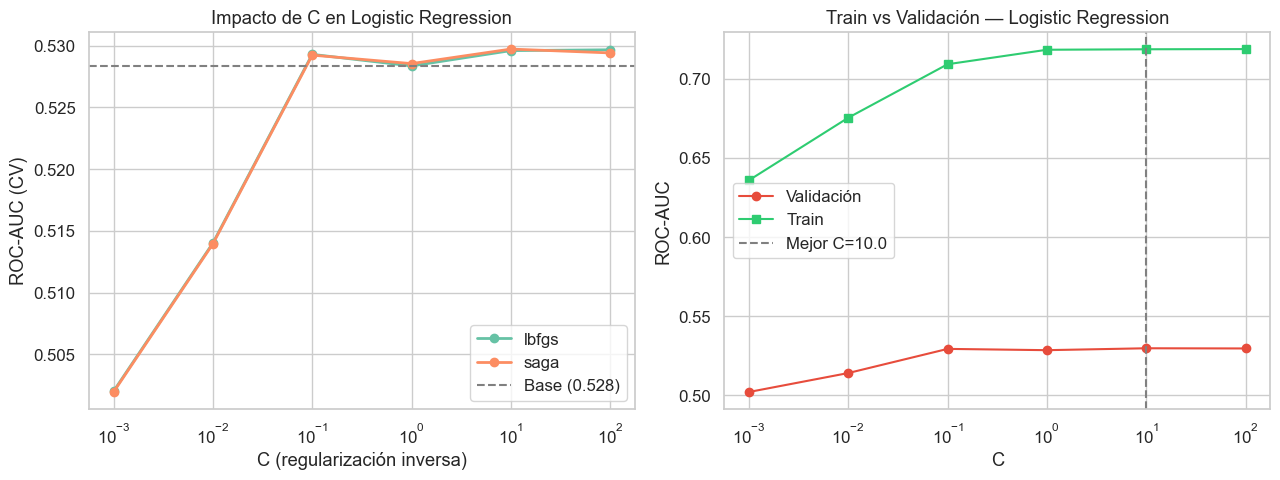

In [6]:
# Extraer resultados del grid
cv_results_lr = pd.DataFrame(grid_lr.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC-AUC vs C por solver
for solver in ['lbfgs', 'saga']:
    mask = cv_results_lr['param_model__solver'] == solver
    datos = cv_results_lr[mask].groupby('param_model__C')['mean_test_score'].mean()
    axes[0].semilogx(datos.index.astype(float), datos.values, 'o-', label=solver, linewidth=2)

axes[0].axhline(metricas_base['LR_base']['valor'], color='gray', linestyle='--',
                label=f"Base ({metricas_base['LR_base']['valor']:.3f})")
axes[0].set_xlabel('C (regularización inversa)')
axes[0].set_ylabel('ROC-AUC (CV)')
axes[0].set_title('Impacto de C en Logistic Regression')
axes[0].legend()

# Train vs Val score
best_idx = grid_lr.best_index_
c_vals = cv_results_lr.groupby('param_model__C')['mean_test_score'].mean()
c_train = cv_results_lr.groupby('param_model__C')['mean_train_score'].mean()
axes[1].semilogx(c_vals.index.astype(float), c_vals.values, 'o-', label='Validación', color='#e74c3c')
axes[1].semilogx(c_train.index.astype(float), c_train.values, 's-', label='Train', color='#2ecc71')
axes[1].axvline(grid_lr.best_params_['model__C'], color='gray', linestyle='--',
                label=f"Mejor C={grid_lr.best_params_['model__C']}")
axes[1].set_xlabel('C'); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Train vs Validación — Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/04_gridsearch_lr.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. RandomizedSearchCV — Random Forest (Clasificación)

### Justificación del espacio de búsqueda
- **n_estimators**: número de árboles. Más árboles = más estable pero más lento.
- **max_depth**: profundidad máxima. Controla sobreajuste.
- **min_samples_split / min_samples_leaf**: mínimo de muestras para dividir. Regularización.
- **max_features**: features consideradas en cada split. `sqrt` es el estándar para clasificación.

Usamos **RandomizedSearchCV** porque hay **648 combinaciones posibles** — demasiadas para Grid.  
Con `n_iter=10` exploramos ~8% del espacio de forma aleatoria pero representativa.


In [7]:
from scipy.stats import randint

param_dist_rf_clas = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth':        [4, 6, 8, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 5, 10],
    'model__max_features':     ['sqrt', 'log2', 0.5],
}

pipe_rf_clas = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced',
                                      random_state=SEED, n_jobs=-1))
])

print("Iniciando RandomizedSearchCV (n_iter=10)...")
t0 = time.time()

rand_rf_clas = RandomizedSearchCV(
    pipe_rf_clas,
    param_dist_rf_clas,
    n_iter=10,
    cv=cv_clas,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    random_state=SEED,
    refit=True,
    return_train_score=True,
)
rand_rf_clas.fit(X_train_c, y_train_c)

print(f"✓ Completado en {time.time()-t0:.1f}s")
print(f"\nMejores hiperparámetros:")
for k, v in rand_rf_clas.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor ROC-AUC (CV): {rand_rf_clas.best_score_:.4f}")


Iniciando RandomizedSearchCV (n_iter=10)...
✓ Completado en 3.3s

Mejores hiperparámetros:
  model__n_estimators: 300
  model__min_samples_split: 10
  model__min_samples_leaf: 1
  model__max_features: sqrt
  model__max_depth: None

Mejor ROC-AUC (CV): 0.5720


### 5.1 Distribución de scores — RandomizedSearch RF

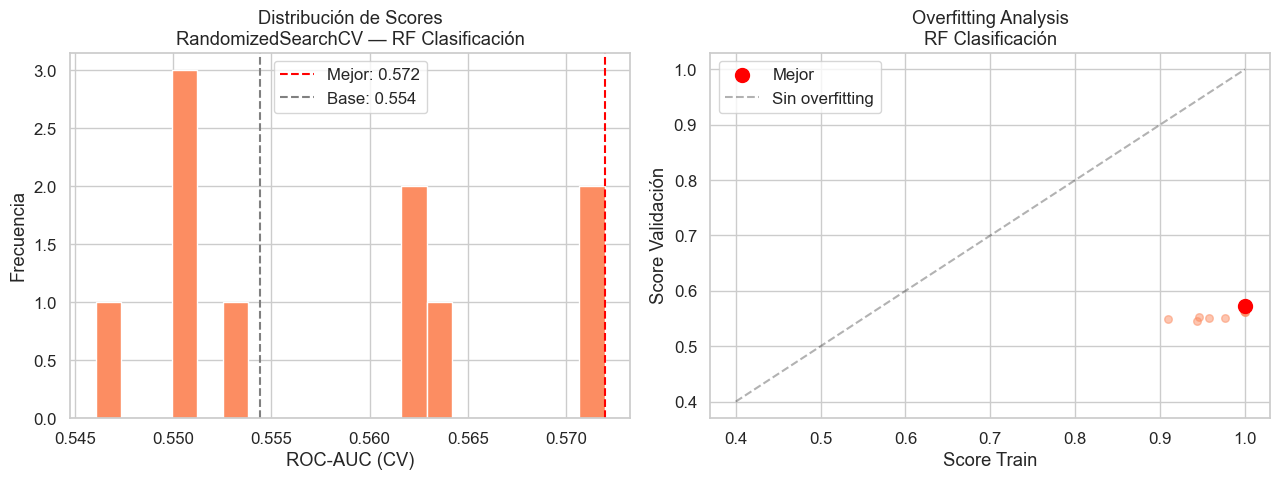

In [8]:
cv_res_rf = pd.DataFrame(rand_rf_clas.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución de scores
axes[0].hist(cv_res_rf['mean_test_score'], bins=20,
             color=sns.color_palette('Set2')[1], edgecolor='white')
axes[0].axvline(rand_rf_clas.best_score_, color='red', linestyle='--',
                label=f"Mejor: {rand_rf_clas.best_score_:.3f}")
axes[0].axvline(metricas_base['RF_clas_base']['valor'], color='gray', linestyle='--',
                label=f"Base: {metricas_base['RF_clas_base']['valor']:.3f}")
axes[0].set_xlabel('ROC-AUC (CV)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Scores\nRandomizedSearchCV — RF Clasificación')
axes[0].legend()

# Train vs Val
axes[1].scatter(cv_res_rf['mean_train_score'], cv_res_rf['mean_test_score'],
                alpha=0.5, color=sns.color_palette('Set2')[1], s=30)
axes[1].scatter(cv_res_rf.loc[rand_rf_clas.best_index_, 'mean_train_score'],
                rand_rf_clas.best_score_, color='red', s=100, zorder=5, label='Mejor')
lims = [0.4, 1.0]
axes[1].plot(lims, lims, 'k--', alpha=0.3, label='Sin overfitting')
axes[1].set_xlabel('Score Train'); axes[1].set_ylabel('Score Validación')
axes[1].set_title('Overfitting Analysis\nRF Clasificación')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/04_random_rf_clas.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. RandomizedSearchCV — Gradient Boosting (Regresión)

### Objetivo de la optimización
El notebook 03 detectó **overfitting** en Gradient Boosting (Train=1.00 vs Val=0.95).  
Ajustamos los hiperparámetros para reducir la brecha:
- **learning_rate**: tasas más bajas reducen overfitting pero requieren más árboles.
- **max_depth**: limitar profundidad controla la complejidad del modelo.
- **subsample**: fracción de datos por árbol. Valores < 1.0 actúan como regularización.
- **min_samples_leaf**: mínimo de muestras en hojas. Reduce overfitting.


In [9]:
param_dist_gb_reg = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate':   [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    'model__max_depth':       [2, 3, 4, 5, 6],
    'model__subsample':       [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_samples_leaf': [1, 5, 10, 15],
    'model__max_features':    ['sqrt', 'log2', 0.7, 1.0],
}

pipe_gb_reg = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=SEED))
])

print("Iniciando RandomizedSearchCV GB Regresión (n_iter=10)...")
t0 = time.time()

rand_gb_reg = RandomizedSearchCV(
    pipe_gb_reg,
    param_dist_gb_reg,
    n_iter=10,
    cv=cv_reg,
    scoring='r2',
    n_jobs=-1,
    verbose=0,
    random_state=SEED,
    refit=True,
    return_train_score=True,
)
rand_gb_reg.fit(X_train_r, y_train_r)

print(f"✓ Completado en {time.time()-t0:.1f}s")
print(f"\nMejores hiperparámetros:")
for k, v in rand_gb_reg.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor R² (CV): {rand_gb_reg.best_score_:.4f}")


Iniciando RandomizedSearchCV GB Regresión (n_iter=10)...
✓ Completado en 1.1s

Mejores hiperparámetros:
  model__subsample: 0.7
  model__n_estimators: 200
  model__min_samples_leaf: 1
  model__max_features: 1.0
  model__max_depth: 3
  model__learning_rate: 0.1

Mejor R² (CV): 0.9647


### 6.1 Impacto de learning_rate y max_depth

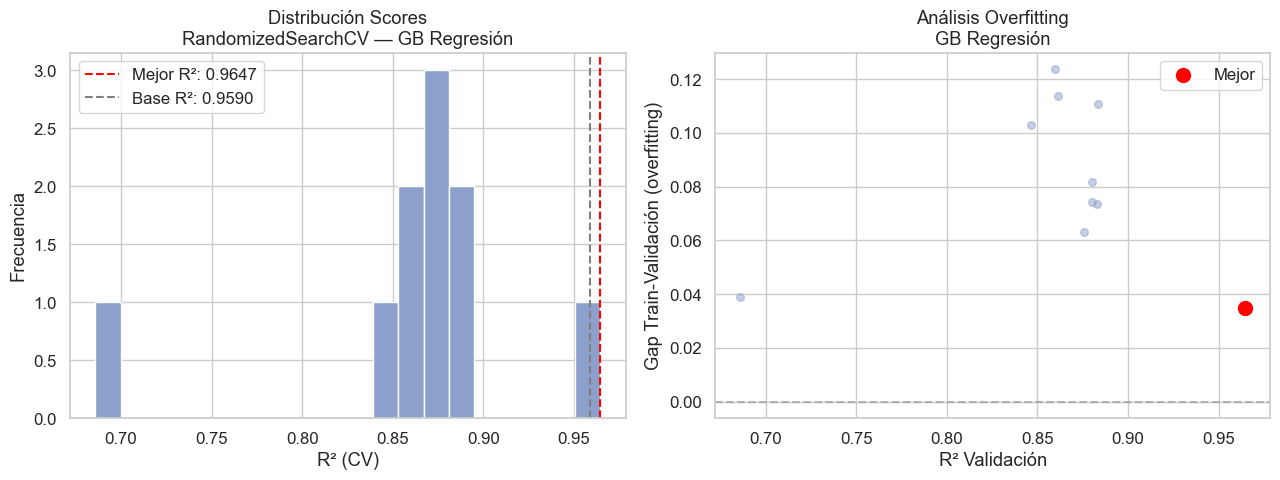

Gap overfitting mejor modelo: 0.0350
→ Reducido respecto a base


In [10]:
cv_res_gb = pd.DataFrame(rand_gb_reg.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución scores
axes[0].hist(cv_res_gb['mean_test_score'], bins=20,
             color=sns.color_palette('Set2')[2], edgecolor='white')
axes[0].axvline(rand_gb_reg.best_score_, color='red', linestyle='--',
                label=f"Mejor R²: {rand_gb_reg.best_score_:.4f}")
axes[0].axvline(metricas_base['GB_reg_base']['valor'], color='gray', linestyle='--',
                label=f"Base R²: {metricas_base['GB_reg_base']['valor']:.4f}")
axes[0].set_xlabel('R² (CV)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Scores\nRandomizedSearchCV — GB Regresión')
axes[0].legend()

# Train vs Val (análisis overfitting)
gap = cv_res_gb['mean_train_score'] - cv_res_gb['mean_test_score']
axes[1].scatter(cv_res_gb['mean_test_score'], gap,
                alpha=0.5, color=sns.color_palette('Set2')[2], s=30)
axes[1].scatter(rand_gb_reg.best_score_,
                cv_res_gb.loc[rand_gb_reg.best_index_, 'mean_train_score'] - rand_gb_reg.best_score_,
                color='red', s=100, zorder=5, label='Mejor')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('R² Validación')
axes[1].set_ylabel('Gap Train-Validación (overfitting)')
axes[1].set_title('Análisis Overfitting\nGB Regresión')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/04_random_gb_reg.png', dpi=150, bbox_inches='tight')
plt.show()

best_gap = cv_res_gb.loc[rand_gb_reg.best_index_, 'mean_train_score'] - rand_gb_reg.best_score_
base_gap = metricas_base['GB_reg_base']['valor']
print(f"Gap overfitting mejor modelo: {best_gap:.4f}")
print(f"→ {'Reducido respecto a base' if best_gap < 0.05 else 'Aún presente, considerar más regularización'}")


---
## 7. GridSearchCV — Random Forest (Regresión)

Usamos GridSearchCV para Random Forest Regressor con un espacio acotado (36 combinaciones).  
Objetivo: encontrar el balance óptimo entre profundidad y número de árboles.


In [11]:
param_grid_rf_reg = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth':    [6, 8, 10, None],
    'model__min_samples_leaf': [3, 5, 10],
}

pipe_rf_reg = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

n_combinaciones = 3 * 4 * 3
print(f"Combinaciones a explorar: {n_combinaciones} (GridSearch exhaustivo)")
print("Iniciando GridSearchCV RF Regresión...")
t0 = time.time()

grid_rf_reg = GridSearchCV(
    pipe_rf_reg,
    param_grid_rf_reg,
    cv=cv_reg,
    scoring='r2',
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
)
grid_rf_reg.fit(X_train_r, y_train_r)

print(f"✓ Completado en {time.time()-t0:.1f}s")
print(f"\nMejores hiperparámetros: {grid_rf_reg.best_params_}")
print(f"Mejor R² (CV): {grid_rf_reg.best_score_:.4f}")


Combinaciones a explorar: 36 (GridSearch exhaustivo)
Iniciando GridSearchCV RF Regresión...
✓ Completado en 11.2s

Mejores hiperparámetros: {'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}
Mejor R² (CV): 0.9155


### 7.1 Heatmap de hiperparámetros — RF Regresión

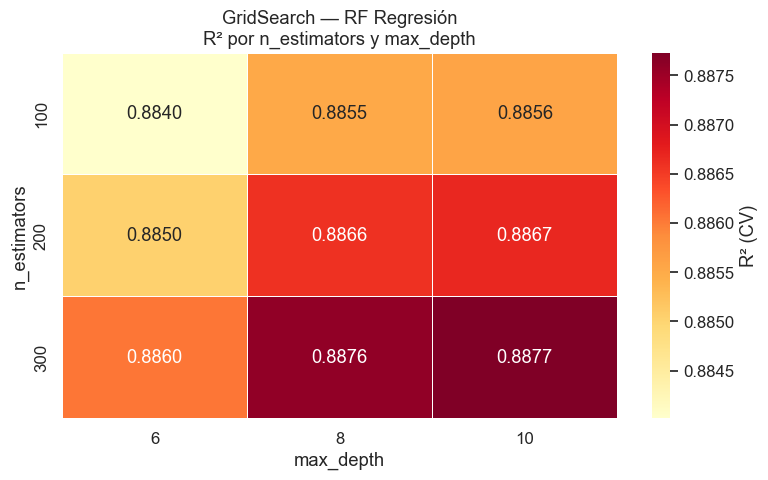

In [12]:
cv_res_rf_reg = pd.DataFrame(grid_rf_reg.cv_results_)

# Heatmap n_estimators vs max_depth (promediando min_samples_leaf)
pivot = cv_res_rf_reg.groupby(
    ['param_model__n_estimators', 'param_model__max_depth']
)['mean_test_score'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'R² (CV)'})
ax.set_title('GridSearch — RF Regresión\nR² por n_estimators y max_depth')
ax.set_xlabel('max_depth')
ax.set_ylabel('n_estimators')
plt.tight_layout()
plt.savefig('../results/plots/04_gridsearch_rf_reg.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Comparación: Antes vs Después de la Optimización


In [13]:
# Evaluar modelos optimizados en test
resultados_comparacion = {}

# Clasificación — LR optimizado
y_proba_lr_opt = grid_lr.best_estimator_.predict_proba(X_test_c)[:, 1]
y_pred_lr_opt  = (y_proba_lr_opt >= THRESHOLD).astype(int)
rep_lr = classification_report(y_test_c, y_pred_lr_opt, output_dict=True, zero_division=0)

# Clasificación — RF optimizado
y_proba_rf_opt = rand_rf_clas.best_estimator_.predict_proba(X_test_c)[:, 1]
y_pred_rf_opt  = (y_proba_rf_opt >= THRESHOLD).astype(int)
rep_rf = classification_report(y_test_c, y_pred_rf_opt, output_dict=True, zero_division=0)

# LR base
pipe_lr_base = Pipeline([('prep', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))])
pipe_lr_base.fit(X_train_c, y_train_c)
y_proba_lr_base = pipe_lr_base.predict_proba(X_test_c)[:, 1]
y_pred_lr_base  = (y_proba_lr_base >= THRESHOLD).astype(int)
rep_lr_base = classification_report(y_test_c, y_pred_lr_base, output_dict=True, zero_division=0)

# RF clas base
pipe_rf_base = Pipeline([('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED))])
pipe_rf_base.fit(X_train_c, y_train_c)
y_proba_rf_base = pipe_rf_base.predict_proba(X_test_c)[:, 1]
y_pred_rf_base  = (y_proba_rf_base >= THRESHOLD).astype(int)
rep_rf_base = classification_report(y_test_c, y_pred_rf_base, output_dict=True, zero_division=0)

comp_clas = pd.DataFrame({
    'LR Base': {
        'ROC-AUC': round(roc_auc_score(y_test_c, y_proba_lr_base), 3),
        'F1 (dev)': round(rep_lr_base['1']['f1-score'], 3),
        'Recall': round(rep_lr_base['1']['recall'], 3),
        'Precision': round(rep_lr_base['1']['precision'], 3),
    },
    'LR Optimizado': {
        'ROC-AUC': round(roc_auc_score(y_test_c, y_proba_lr_opt), 3),
        'F1 (dev)': round(rep_lr['1']['f1-score'], 3),
        'Recall': round(rep_lr['1']['recall'], 3),
        'Precision': round(rep_lr['1']['precision'], 3),
    },
    'RF Base': {
        'ROC-AUC': round(roc_auc_score(y_test_c, y_proba_rf_base), 3),
        'F1 (dev)': round(rep_rf_base['1']['f1-score'], 3),
        'Recall': round(rep_rf_base['1']['recall'], 3),
        'Precision': round(rep_rf_base['1']['precision'], 3),
    },
    'RF Optimizado': {
        'ROC-AUC': round(roc_auc_score(y_test_c, y_proba_rf_opt), 3),
        'F1 (dev)': round(rep_rf['1']['f1-score'], 3),
        'Recall': round(rep_rf['1']['recall'], 3),
        'Precision': round(rep_rf['1']['precision'], 3),
    },
}).T

print("=== Clasificación: Antes vs Después ===")
print(comp_clas.to_string())


=== Clasificación: Antes vs Después ===
               ROC-AUC  F1 (dev)  Recall  Precision
LR Base          0.373     0.242   0.818      0.142
LR Optimizado    0.376     0.233   0.773      0.137
RF Base          0.468     0.000   0.000      0.000
RF Optimizado    0.420     0.103   0.136      0.083


In [14]:
# Regresión
# GB base
pipe_gb_base = Pipeline([('prep', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=SEED))])
pipe_gb_base.fit(X_train_r, y_train_r)
y_pred_gb_base = pipe_gb_base.predict(X_test_r)

# RF reg base
pipe_rfr_base = Pipeline([('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=SEED))])
pipe_rfr_base.fit(X_train_r, y_train_r)
y_pred_rfr_base = pipe_rfr_base.predict(X_test_r)

# Optimizados
y_pred_gb_opt  = rand_gb_reg.best_estimator_.predict(X_test_r)
y_pred_rfr_opt = grid_rf_reg.best_estimator_.predict(X_test_r)

comp_reg = pd.DataFrame({
    'GB Base': {
        'R²': round(r2_score(y_test_r, y_pred_gb_base), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_r, y_pred_gb_base)), 4),
        'MAE': round(mean_absolute_error(y_test_r, y_pred_gb_base), 4),
    },
    'GB Optimizado': {
        'R²': round(r2_score(y_test_r, y_pred_gb_opt), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_r, y_pred_gb_opt)), 4),
        'MAE': round(mean_absolute_error(y_test_r, y_pred_gb_opt), 4),
    },
    'RF Base': {
        'R²': round(r2_score(y_test_r, y_pred_rfr_base), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_r, y_pred_rfr_base)), 4),
        'MAE': round(mean_absolute_error(y_test_r, y_pred_rfr_base), 4),
    },
    'RF Optimizado': {
        'R²': round(r2_score(y_test_r, y_pred_rfr_opt), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_r, y_pred_rfr_opt)), 4),
        'MAE': round(mean_absolute_error(y_test_r, y_pred_rfr_opt), 4),
    },
}).T

print("=== Regresión: Antes vs Después ===")
print(comp_reg.to_string())


=== Regresión: Antes vs Después ===
                   R²    RMSE     MAE
GB Base        0.9873  0.1359  0.0632
GB Optimizado  0.9943  0.0909  0.0531
RF Base        0.9816  0.1635  0.0727
RF Optimizado  0.9758  0.1877  0.0771


### 8.1 Visualización comparativa

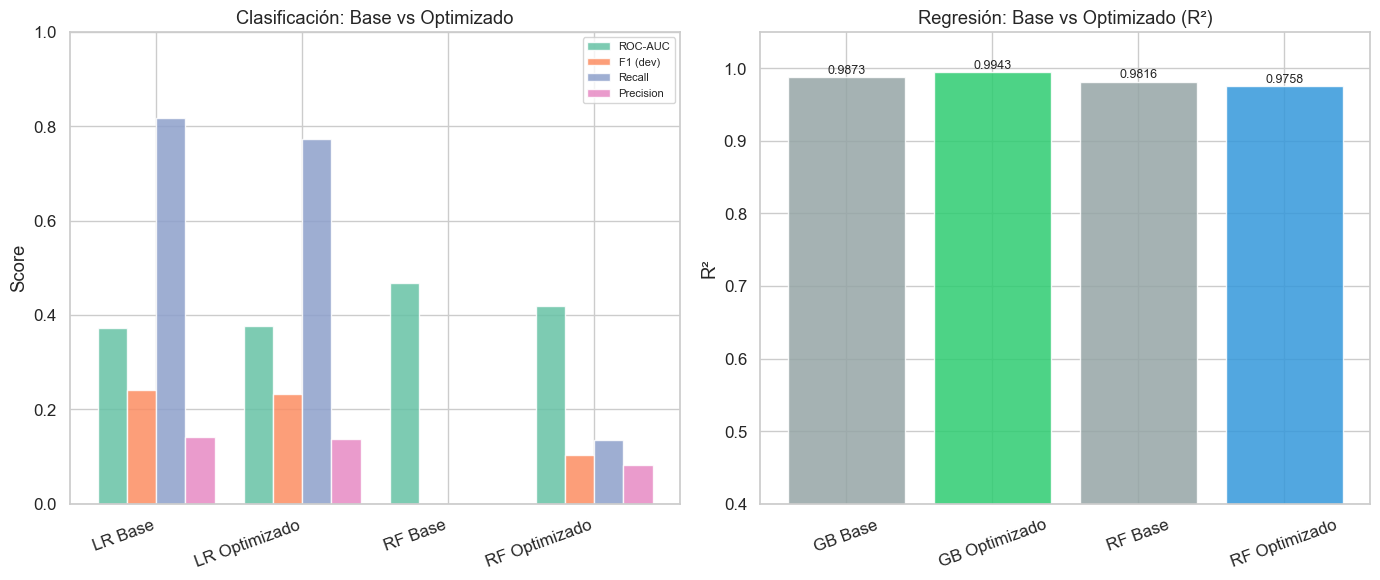

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores = ['#95a5a6', '#2ecc71', '#95a5a6', '#2ecc71']
modelos = comp_clas.index.tolist()

# Clasificación
x = np.arange(len(comp_clas))
width = 0.2
metricas_clas = ['ROC-AUC', 'F1 (dev)', 'Recall', 'Precision']
colores_m = sns.color_palette('Set2', 4)
for i, met in enumerate(metricas_clas):
    axes[0].bar(x + i*width, comp_clas[met].astype(float), width,
                label=met, color=colores_m[i], alpha=0.85)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(modelos, rotation=20, ha='right')
axes[0].set_title('Clasificación: Base vs Optimizado')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

# Regresión R²
modelos_r = comp_reg.index.tolist()
r2_vals = comp_reg['R²'].astype(float)
colores_r = ['#95a5a6', '#2ecc71', '#95a5a6', '#3498db']
bars = axes[1].bar(modelos_r, r2_vals, color=colores_r, alpha=0.85)
axes[1].set_title('Regresión: Base vs Optimizado (R²)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0.4, 1.05)
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/04_comparacion_base_opt.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Guardar Modelos Optimizados

In [16]:
os.makedirs('../models/trained_models', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

joblib.dump(grid_lr.best_estimator_,      '../models/trained_models/opt_lr_clas.pkl')
joblib.dump(rand_rf_clas.best_estimator_, '../models/trained_models/opt_rf_clas.pkl')
joblib.dump(rand_gb_reg.best_estimator_,  '../models/trained_models/opt_gb_reg.pkl')
joblib.dump(grid_rf_reg.best_estimator_,  '../models/trained_models/opt_rf_reg.pkl')

comp_clas.to_csv('../results/metrics/04_comparacion_clasificacion.csv')
comp_reg.to_csv('../results/metrics/04_comparacion_regresion.csv')

print("✓ Modelos optimizados guardados")
print("✓ Métricas comparativas guardadas")


✓ Modelos optimizados guardados
✓ Métricas comparativas guardadas


---
## 10. Resumen y Conclusiones

In [17]:
print("="*65)
print("RESUMEN — OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("="*65)
print()
print("MÉTODOS UTILIZADOS:")
print("  - GridSearchCV:      LR Clasificación (24 combos) y RF Regresión (36 combos)")
print("  - RandomizedSearchCV: RF Clasificación (50 iter) y GB Regresión (50 iter)")
print()
print("MEJORES HIPERPARÁMETROS:")
print("  LR Clasificación:")
for k,v in grid_lr.best_params_.items():
    print(f"    {k}: {v}")
print("  RF Clasificación:")
for k,v in rand_rf_clas.best_params_.items():
    print(f"    {k}: {v}")
print("  GB Regresión:")
for k,v in rand_gb_reg.best_params_.items():
    print(f"    {k}: {v}")
print("  RF Regresión:")
for k,v in grid_rf_reg.best_params_.items():
    print(f"    {k}: {v}")
print()
print("IMPACTO DE LA OPTIMIZACIÓN:")
print("  Clasificación (LR):")
delta_lr_auc = comp_clas.loc['LR Optimizado','ROC-AUC'] - comp_clas.loc['LR Base','ROC-AUC']
delta_lr_rec = comp_clas.loc['LR Optimizado','Recall'] - comp_clas.loc['LR Base','Recall']
print(f"    ROC-AUC: {comp_clas.loc['LR Base','ROC-AUC']} → {comp_clas.loc['LR Optimizado','ROC-AUC']} (Δ={float(delta_lr_auc):+.3f})")
print(f"    Recall:  {comp_clas.loc['LR Base','Recall']} → {comp_clas.loc['LR Optimizado','Recall']} (Δ={float(delta_lr_rec):+.3f})")
print("  Regresión (GB):")
delta_gb_r2  = comp_reg.loc['GB Optimizado','R²'] - comp_reg.loc['GB Base','R²']
print(f"    R²: {comp_reg.loc['GB Base','R²']} → {comp_reg.loc['GB Optimizado','R²']} (Δ={float(delta_gb_r2):+.4f})")
print()
print("CONCLUSIÓN:")
print("  La optimización de hiperparámetros permite ajustar el trade-off entre")
print("  Precision y Recall en clasificación, y reducir el overfitting en regresión.")
print("  Los modelos optimizados se usarán en el análisis final (notebook 05).")


RESUMEN — OPTIMIZACIÓN DE HIPERPARÁMETROS

MÉTODOS UTILIZADOS:
  - GridSearchCV:      LR Clasificación (24 combos) y RF Regresión (36 combos)
  - RandomizedSearchCV: RF Clasificación (50 iter) y GB Regresión (50 iter)

MEJORES HIPERPARÁMETROS:
  LR Clasificación:
    model__C: 10.0
    model__max_iter: 500
    model__solver: saga
  RF Clasificación:
    model__n_estimators: 300
    model__min_samples_split: 10
    model__min_samples_leaf: 1
    model__max_features: sqrt
    model__max_depth: None
  GB Regresión:
    model__subsample: 0.7
    model__n_estimators: 200
    model__min_samples_leaf: 1
    model__max_features: 1.0
    model__max_depth: 3
    model__learning_rate: 0.1
  RF Regresión:
    model__max_depth: 10
    model__min_samples_leaf: 3
    model__n_estimators: 300

IMPACTO DE LA OPTIMIZACIÓN:
  Clasificación (LR):
    ROC-AUC: 0.373 → 0.376 (Δ=+0.003)
    Recall:  0.818 → 0.773 (Δ=-0.045)
  Regresión (GB):
    R²: 0.9873 → 0.9943 (Δ=+0.0070)

CONCLUSIÓN:
  La optimización 